# 01 · Exploración, particiones y fugas

Ejecutar todas las celdas en orden. Datos históricos y simulaciones educativas; no representan una aplicación financiera real.

In [1]:
from pathlib import Path
import sys, os
os.environ["EVIDENTLY_DO_NOT_TRACK"]="1"
base=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/"_config.yml").exists())
project=base/"actividad_3/proyecto_inicial"
sys.path.insert(0,str(project/"src"))
os.environ["BANK_ROOT"]=str(project)
import numpy as np, pandas as pd
from bank_ops.data import load, partitions
from bank_ops.config import FEATURES, SEED
from bank_ops.model import pipeline, metrics
data=load(); train,validation,test=partitions(data)


## Inspeccionar antes de entrenar
Comparar tamaños y prevalencias. No inventar fechas completas a partir del orden.

In [2]:
summary=pd.DataFrame([{"particion":n,"n":len(f),"prevalencia":(f.y=="yes").mean(),"inicio":f.row_id.min(),"fin":f.row_id.max()} for n,f in [("train",train),("validation",validation),("test",test)]])
display(summary);display(data.head())

,particion,n,prevalencia,inicio,fin
0,train,27126,0.050394,0,27125
1,validation,9042,0.117894,27126,36167
2,test,9043,0.315824,36168,45210


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,row_id
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no,2
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no,3
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no,4


In [3]:
assert len(data)==45211
assert train.row_id.max()<validation.row_id.min()<test.row_id.min()
assert not {"duration","age","day","y","row_id"}&set(FEATURES)
display(data[FEATURES].isna().sum().to_frame("nulos"))

,nulos
balance,0
campaign,0
pdays,0
previous,0
job,0
marital,0
education,0
default,0
housing,0
loan,0


## La trampa de duration
Su asociación con el target no justifica incluir información posterior al momento de predicción.

,count,mean,median
y,,,
no,39922,221.182806,164.0
yes,5289,537.294574,426.0


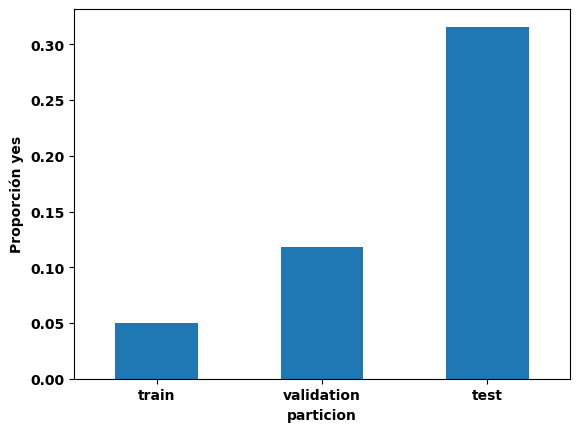

In [4]:
display(data.groupby("y").duration.agg(["count","mean","median"]))
import matplotlib.pyplot as plt
summary.plot.bar(x="particion",y="prevalencia",rot=0,legend=False)
plt.ylabel("Proporción yes");plt.show()

## Reflexión
¿Qué cambia entre particiones? ¿Qué incertidumbre introduce no tener identificador de persona? Evite afirmar causalidad sin evidencia.

## Profundización avanzada

Experimentos de estudio opcionales. No añaden entregables ni resuelven las tareas obligatorias del proyecto inicial.

### Hipótesis 1: magnitud y significancia aportan información diferente
Construimos dos controles sin filas compartidas en validation y una intervención solo sobre balance. Las distancias se calculan sobre valores originales, sin el recorte usado a veces para visualizar. La normalización por IQR es una convención explícita de este experimento, no la fórmula interna de Evidently. KS presupone condiciones de muestreo que el CSV histórico no permite garantizar por persona o tiempo.

In [5]:
from scipy.stats import ks_2samp, wasserstein_distance
pool=validation.sample(frac=1,random_state=SEED)
ref=pool.iloc[:1500].copy();cur=pool.iloc[1500:3000].copy()
iqr=float(ref.balance.quantile(.75)-ref.balance.quantile(.25))
assert iqr>0
rows=[]
for shift in [0,100,1000,12000]:
    values=cur.balance.to_numpy()+shift
    ks=ks_2samp(ref.balance,values)
    distance=wasserstein_distance(ref.balance,values)
    rows.append({"desplazamiento":shift,"KS_D":ks.statistic,"p_value":ks.pvalue,
                 "W1_balance":distance,"W1_sobre_IQR":distance/iqr})
drift_table=pd.DataFrame(rows)
display(drift_table)
assert (drift_table.W1_balance>=0).all()

,desplazamiento,KS_D,p_value,W1_balance,W1_sobre_IQR
0,0,0.044667,1.002948e-01,92.456667,0.075336
1,100,0.154667,4.569921e-16,94.262000,0.076807
2,1000,0.603333,1.793457e-254,972.504667,0.792426
3,12000,0.984667,0.000000e+00,11970.303333,9.753761


**Lectura:** el control sin desplazamiento tampoco tiene distancia exactamente cero: son dos muestras. Compare la magnitud en unidades de balance con el p-valor y con la intervención conocida. No use el p-valor como probabilidad de degradación. La diferencia entre muestras y la perturbación son componentes distintos del experimento.

In [6]:
def total_variation(a,b):
    p=a.value_counts(normalize=True);q=b.value_counts(normalize=True)
    categories=p.index.union(q.index)
    return float(.5*(p.reindex(categories,fill_value=0)-q.reindex(categories,fill_value=0)).abs().sum())
categorical=pd.DataFrame({"escenario":["control","contact desconocido"],
                         "TV":[total_variation(ref.contact,cur.contact),
                               total_variation(ref.contact,pd.Series("unknown",index=cur.index))]})
display(categorical)
assert categorical.TV.between(0,1).all()

,escenario,TV
0,control,0.002667
1,contact desconocido,1.000000


### Hipótesis 2: las marginales no identifican toda la distribución conjunta
El siguiente ejemplo es sintético y exacto. Conserva proporciones de cada columna y cambia por completo su asociación. No pretende demostrar que esa inversión ocurra en UCI.

,referencia,actual
X1,0.5,0.5
X2,0.5,0.5


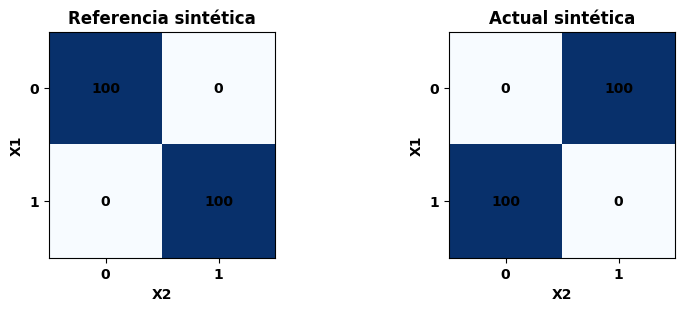

In [7]:
import matplotlib.pyplot as plt
r=np.array([[0,0],[1,1]]*100);c=np.array([[0,1],[1,0]]*100)
assert np.array_equal(r.mean(axis=0),c.mean(axis=0))
display(pd.DataFrame({"referencia":r.mean(axis=0),"actual":c.mean(axis=0)},index=["X1","X2"]))
fig,axes=plt.subplots(1,2,figsize=(8,3),constrained_layout=True)
for ax,values,title in zip(axes,[r,c],["Referencia sintética","Actual sintética"]):
    counts=pd.crosstab(values[:,0],values[:,1]).reindex(index=[0,1],columns=[0,1],fill_value=0)
    ax.imshow(counts,vmin=0,vmax=100,cmap="Blues")
    for i in range(2):
        for j in range(2):ax.text(j,i,str(counts.iloc[i,j]),ha="center",va="center")
    ax.set(xticks=[0,1],yticks=[0,1],xlabel="X2",ylabel="X1",title=title)
plt.show()

**Preguntas de cierre:** ¿qué detector por columna permanecería ciego al segundo experimento?, ¿qué asociación relevante revisaría en el caso real?, ¿qué dato adicional necesitaría para relacionar una señal con pérdida predictiva? Una respuesta válida debe distinguir construcción sintética, observación histórica e hipótesis causal.